In [1]:
import os
import sys
from pathlib import Path

library_path = os.path.abspath('../src')
if library_path not in sys.path:
    sys.path.append(library_path)
library_path = Path(library_path)

In [2]:
import pandas as pd
from pandas.io.stata import StataReader

In [3]:
# load data
DATA_PATH = library_path.parent / "data"
PLOTS_PATH = library_path.parent / "plots"

cols_to_use = [
    "dataset", "Region", "MO5L", "SC5L", "UA5L", "PD5L", "AD5L", "EQvas", "srh", "sat", "mo2cat", "sc2cat",
    "ua2cat", "pd2cat", "ad2cat", "FULLHEALTH", "anyprob", "util_rowen", "LSS_rs", "EQ_index", "age7cat", "Sex",
    "eth4cat", "emp_cat", "edu_cat", "educ_pst", "smoke_ever", "smoke_ecig", "alcohol_yr", "diabetes",
    "obese", "resp", "bowel", "mus", "skin"
]

In [4]:
# Create reader object
reader = StataReader(DATA_PATH / 'Pop_Data_Appended_NoPopcorn.dta', columns=cols_to_use)

# Extract variable labels
var_labels = reader.variable_labels()

# Extract value labels
val_labels = reader.value_labels()

# Extract the entire dataset
df = reader.read()

/tmp/ipykernel_316008/127024535.py:5: UnicodeWarning: 
One or more strings in the dta file could not be decoded using utf-8, and
so the fallback encoding of latin-1 is being used.  This can happen when a file
has been incorrectly encoded by Stata or some other software. You should verify
the string values returned are correct.
  var_labels = reader.variable_labels()
/tmp/ipykernel_316008/127024535.py:8: UnicodeWarning: 
One or more strings in the dta file could not be decoded using utf-8, and
so the fallback encoding of latin-1 is being used.  This can happen when a file
has been incorrectly encoded by Stata or some other software. You should verify
the string values returned are correct.
  val_labels = reader.value_labels()


In [5]:
df.head()

,dataset,Region,MO5L,SC5L,UA5L,PD5L,AD5L,EQvas,srh,sat,...,educ_pst,smoke_ever,smoke_ecig,alcohol_yr,diabetes,obese,resp,bowel,mus,skin
0,HSE 2017,NaN,No Problems,No Problems,No Problems,No Problems,No Problems,100.0,Very good/Excellent,9.0,...,NaN,yes,no,monthly+,NaN,NaN,0.0,NaN,NaN,0.0
1,HSE 2017,NaN,Slight,No Problems,No Problems,Moderate,Slight,75.0,Good/fair,7.0,...,NaN,NaN,yes,weekly+,NaN,0.0,0.0,NaN,NaN,0.0
2,HSE 2017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Fair/bad,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,0.0
3,HSE 2017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Very good/Excellent,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,0.0
4,HSE 2017,NaN,No Problems,No Problems,No Problems,No Problems,No Problems,90.0,Very good/Good,9.0,...,NaN,NaN,no,weekly+,NaN,1.0,0.0,NaN,NaN,0.0


# Exploratory Analysis

This section profiles the loaded dataframe with quick structural checks, missingness, summary tables, and a few diagnostic plots.

In [6]:
import math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

PLOTS_PATH.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

numeric_cols = df.select_dtypes(include="number").columns.tolist()
categorical_like_cols = [
    col for col in df.columns
    if df[col].dtype == "object" or df[col].nunique(dropna=True) <= 10
]
continuous_cols = [
    col for col in numeric_cols
    if col not in categorical_like_cols and df[col].nunique(dropna=True) > 10
]

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print(f"Numeric columns: {len(numeric_cols)}")
print(f"Categorical-like columns: {len(categorical_like_cols)}")
print(f"Continuous columns: {len(continuous_cols)}")

Rows: 57,425
Columns: 35
Numeric columns: 12
Categorical-like columns: 30
Continuous columns: 5


In [7]:
overview = pd.DataFrame(
    {
        "dtype": df.dtypes.astype(str),
        "missing": df.isna().sum(),
        "missing_pct": df.isna().mean().mul(100),
        "n_unique": df.nunique(dropna=True),
    }
).sort_values(["missing_pct", "n_unique"], ascending=[False, False])

print("First five rows")
display(df.head())

print("Column overview")
display(overview)

missing_only = overview.loc[overview["missing"] > 0, ["missing", "missing_pct"]]
if not missing_only.empty:
    print("Columns with missing values")
    display(missing_only)
else:
    print("No missing values detected.")

First five rows


,dataset,Region,MO5L,SC5L,UA5L,PD5L,AD5L,EQvas,srh,sat,mo2cat,sc2cat,ua2cat,pd2cat,ad2cat,FULLHEALTH,anyprob,util_rowen,LSS_rs,EQ_index,age7cat,Sex,eth4cat,emp_cat,edu_cat,educ_pst,smoke_ever,smoke_ecig,alcohol_yr,diabetes,obese,resp,bowel,mus,skin
0,HSE 2017,NaN,No Problems,No Problems,No Problems,No Problems,No Problems,100.000,Very good/Excellent,9.000,No Problems,No Problems,No Problems,No Problems,No Problems,Full Health,No Problems,1.000,100.000,1.000,6.000,Male,White,Employed,Degree or equivalent,NaN,yes,no,monthly+,NaN,NaN,0.000,NaN,NaN,0.000
1,HSE 2017,NaN,Slight,No Problems,No Problems,Moderate,Slight,75.000,Good/fair,7.000,Any Problems,No Problems,No Problems,Any Problems,Any Problems,Has problems,Has Problems,0.861,80.000,0.861,2.000,Female,White,Employed,Below degree,NaN,NaN,yes,weekly+,NaN,0.000,0.000,NaN,NaN,0.000
2,HSE 2017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Fair/bad,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000,NaN,NaN,-1.000,Female,White,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000,NaN,NaN,0.000
3,HSE 2017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Very good/Excellent,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000,NaN,NaN,-1.000,Female,White,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000,NaN,NaN,0.000
4,HSE 2017,NaN,No Problems,No Problems,No Problems,No Problems,No Problems,90.000,Very good/Good,9.000,No Problems,No Problems,No Problems,No Problems,No Problems,Full Health,No Problems,1.000,100.000,1.000,3.000,Male,White,Employed,Degree or equivalent,NaN,NaN,no,weekly+,NaN,1.000,0.000,NaN,NaN,0.000


Column overview


,dtype,missing,missing_pct,n_unique
Region,category,52187,90.879,4
bowel,float32,48171,83.885,2
diabetes,float32,47685,83.039,2
EQvas,float32,36568,63.680,101
EQ_index,float32,36234,63.098,659
LSS_rs,float32,36234,63.098,21
FULLHEALTH,category,36234,63.098,2
anyprob,category,36234,63.098,2
AD5L,category,36028,62.739,5
ad2cat,category,36028,62.739,2


Columns with missing values


,missing,missing_pct
Region,52187,90.879
bowel,48171,83.885
diabetes,47685,83.039
EQvas,36568,63.680
EQ_index,36234,63.098
LSS_rs,36234,63.098
FULLHEALTH,36234,63.098
anyprob,36234,63.098
AD5L,36028,62.739
ad2cat,36028,62.739


Continuous-variable summary


,count,mean,std,min,25%,50%,75%,max
EQvas,"20,857.000",75.567,20.217,0.000,68.000,80.000,90.000,100.000
LSS_rs,"21,191.000",88.144,16.430,0.000,85.000,95.000,100.000,100.000
sat,"29,095.000",7.445,2.053,0.000,7.000,8.000,9.000,10.000
EQ_index,"21,191.000",0.864,0.227,-0.567,0.854,0.944,1.000,1.000
util_rowen,"38,004.000",0.923,0.184,-0.567,0.944,1.000,1.000,1.000


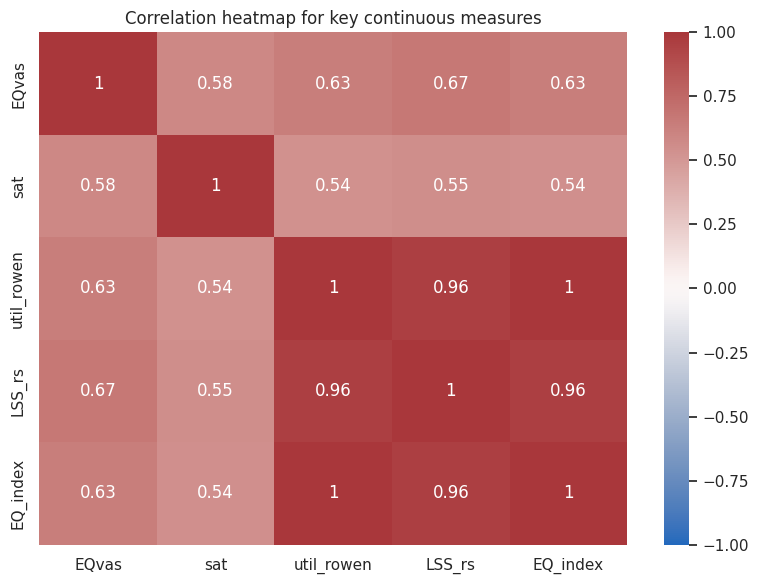

In [8]:
if continuous_cols:
    numeric_summary = df[continuous_cols].describe().T.sort_values("std", ascending=False)
    print("Continuous-variable summary")
    display(numeric_summary)

    corr_candidates = [
        col for col in ["EQvas", "srh", "sat", "util_rowen", "LSS_rs", "EQ_index"]
        if col in continuous_cols
    ]
    if len(corr_candidates) >= 2:
        corr = df[corr_candidates].corr(numeric_only=True)
        plt.figure(figsize=(8, 6))
        sns.heatmap(corr, annot=True, cmap="vlag", vmin=-1, vmax=1)
        plt.title("Correlation heatmap for key continuous measures")
        plt.tight_layout()
        plt.savefig(PLOTS_PATH / "correlation_heatmap.png", dpi=150, bbox_inches="tight")
        plt.show()
else:
    print("No continuous columns detected with the current heuristic.")

In [9]:
if "Region" not in df.columns:
    raise KeyError("Region column is not available in the dataframe.")

original_rows = len(df)
missing_region = int(df["Region"].isna().sum())
non_england_rows = int(df["Region"].notna().sum() - df["Region"].eq("England").sum())

df["Region"] = df["Region"].astype("string").fillna("England")
df = df.loc[df["Region"] == "England"].copy()

numeric_cols = df.select_dtypes(include="number").columns.tolist()
categorical_like_cols = [
    col for col in df.columns
    if df[col].dtype == "object" or str(df[col].dtype) == "string" or df[col].nunique(dropna=True) <= 10
]
continuous_cols = [
    col for col in numeric_cols
    if col not in categorical_like_cols and df[col].nunique(dropna=True) > 10
]

print(f"Filled {missing_region:,} missing Region values with 'England'.")
print(f"Dropped {non_england_rows:,} rows that were not England.")
print(f"Rows retained: {len(df):,} of {original_rows:,}")
print(df["Region"].value_counts(dropna=False))

df = df.drop(columns=["Region"], inplace=False)

Filled 52,187 missing Region values with 'England'.
Dropped 738 rows that were not England.
Rows retained: 56,687 of 57,425
Region
England    56687
Name: count, dtype: Int64


In [10]:
df['dataset'] = df['dataset'].apply(lambda x: 'DAPHNIE 2023' if 'Pilot' in x else x)

In [11]:
if "diabetes" not in df.columns:
    raise KeyError("diabetes column is not available in the dataframe.")

missing_diabetes = int(df["diabetes"].isna().sum())
diabetes_series = df["diabetes"]

if isinstance(diabetes_series.dtype, pd.CategoricalDtype):
    if 0 not in diabetes_series.cat.categories and 0.0 not in diabetes_series.cat.categories:
        diabetes_series = diabetes_series.cat.add_categories([0.0])
    df["diabetes"] = diabetes_series.fillna(0.0)
else:
    df["diabetes"] = diabetes_series.fillna(0)

print(f"Filled {missing_diabetes:,} missing diabetes values with 0.")
print(df["diabetes"].value_counts(dropna=False))

Filled 47,628 missing diabetes values with 0.
diabetes
0.000    53526
1.000     3161
Name: count, dtype: int64


In [21]:
if "age7cat" not in df.columns:
    raise KeyError("age7cat column is not available in the dataframe.")

age7cat_numeric = pd.to_numeric(df["age7cat"], errors="coerce")
drop_mask = age7cat_numeric.isin([-1, 0])
dropped_age7cat_rows = int(drop_mask.sum())
rows_before_age7cat_filter = len(df)

df = df.loc[~drop_mask].copy()

numeric_cols = df.select_dtypes(include="number").columns.tolist()
categorical_like_cols = [
    col for col in df.columns
    if df[col].dtype == "object" or str(df[col].dtype) == "string" or df[col].nunique(dropna=True) <= 10
]
continuous_cols = [
    col for col in numeric_cols
    if col not in categorical_like_cols and df[col].nunique(dropna=True) > 10
]

print(f"Dropped {dropped_age7cat_rows:,} rows where age7cat was -1 or 0.")
print(f"Rows retained: {len(df):,} of {rows_before_age7cat_filter:,}")
print(df["age7cat"].value_counts(dropna=False).sort_index())

Dropped 0 rows where age7cat was -1 or 0.
Rows retained: 49,141 of 49,141
age7cat
1.000    3405
2.000    6010
3.000    7438
4.000    7513
5.000    7866
6.000    7853
7.000    5085
NaN      3971
Name: count, dtype: int64


## Categorical Variables

This block profiles categorical and categorical-like variables, highlights missingness and class imbalance, and compares their distributions across datasets when available.

In [18]:
priority_categoricals = [
    column
    for column in [
        "dataset", "Sex", "age7cat", "eth4cat", "emp_cat", "edu_cat", "educ_pst",
        "smoke_ever", "smoke_ecig", "alcohol_yr", "diabetes", "obese", "resp", "bowel", "mus", "skin",
        "MO5L", "SC5L", "UA5L", "PD5L", "AD5L", "mo2cat", "sc2cat", "ua2cat", "pd2cat", "ad2cat",
        "FULLHEALTH", "anyprob"
    ]
    if column in categorical_like_cols
]
if not priority_categoricals:
    priority_categoricals = categorical_like_cols[:12]


def category_display_series(series):
    return series.astype("string").fillna("Missing")


def top_category_stats(series):
    counts = category_display_series(series).value_counts(dropna=False)
    top_value = counts.index[0]
    top_count = int(counts.iloc[0])
    top_pct = float(counts.iloc[0] / len(series) * 100)
    return top_value, top_count, top_pct


summary_rows = []
for column in priority_categoricals:
    top_value, top_count, top_pct = top_category_stats(df[column])
    summary_rows.append(
        {
            "column": column,
            "label": var_labels.get(column, column),
            "dtype": str(df[column].dtype),
            "missing": int(df[column].isna().sum()),
            "missing_pct": float(df[column].isna().mean() * 100),
            "n_unique": int(df[column].nunique(dropna=True)),
            "top_value": top_value,
            "top_count": top_count,
            "top_pct": top_pct,
        }
    )

category_summary = (
    pd.DataFrame(summary_rows)
    .set_index("column")
    .sort_values(["missing_pct", "top_pct", "n_unique"], ascending=[False, False, True])
)

print("Categorical-variable summary")
display(category_summary)

Categorical-variable summary


,label,dtype,missing,missing_pct,n_unique,top_value,top_count,top_pct
column,,,,,,,,
bowel,,float32,40569,82.556,2,Missing,40569,82.556
FULLHEALTH,Full Health (11111),category,28677,58.357,2,Missing,28677,58.357
anyprob,Any Problems Reported,category,28677,58.357,2,Missing,28677,58.357
ad2cat,Anxiety/Depression Problems (Binary),category,28476,57.948,2,Missing,28476,57.948
AD5L,Anxiety/Depression (5L),category,28476,57.948,5,Missing,28476,57.948
sc2cat,Self-Care Problems (Binary),category,28453,57.901,2,Missing,28453,57.901
SC5L,Self-Care (5L),category,28453,57.901,5,Missing,28453,57.901
pd2cat,Pain/Discomfort Problems (Binary),category,28448,57.891,2,Missing,28448,57.891
PD5L,Pain/Discomfort (5L),category,28448,57.891,5,Missing,28448,57.891


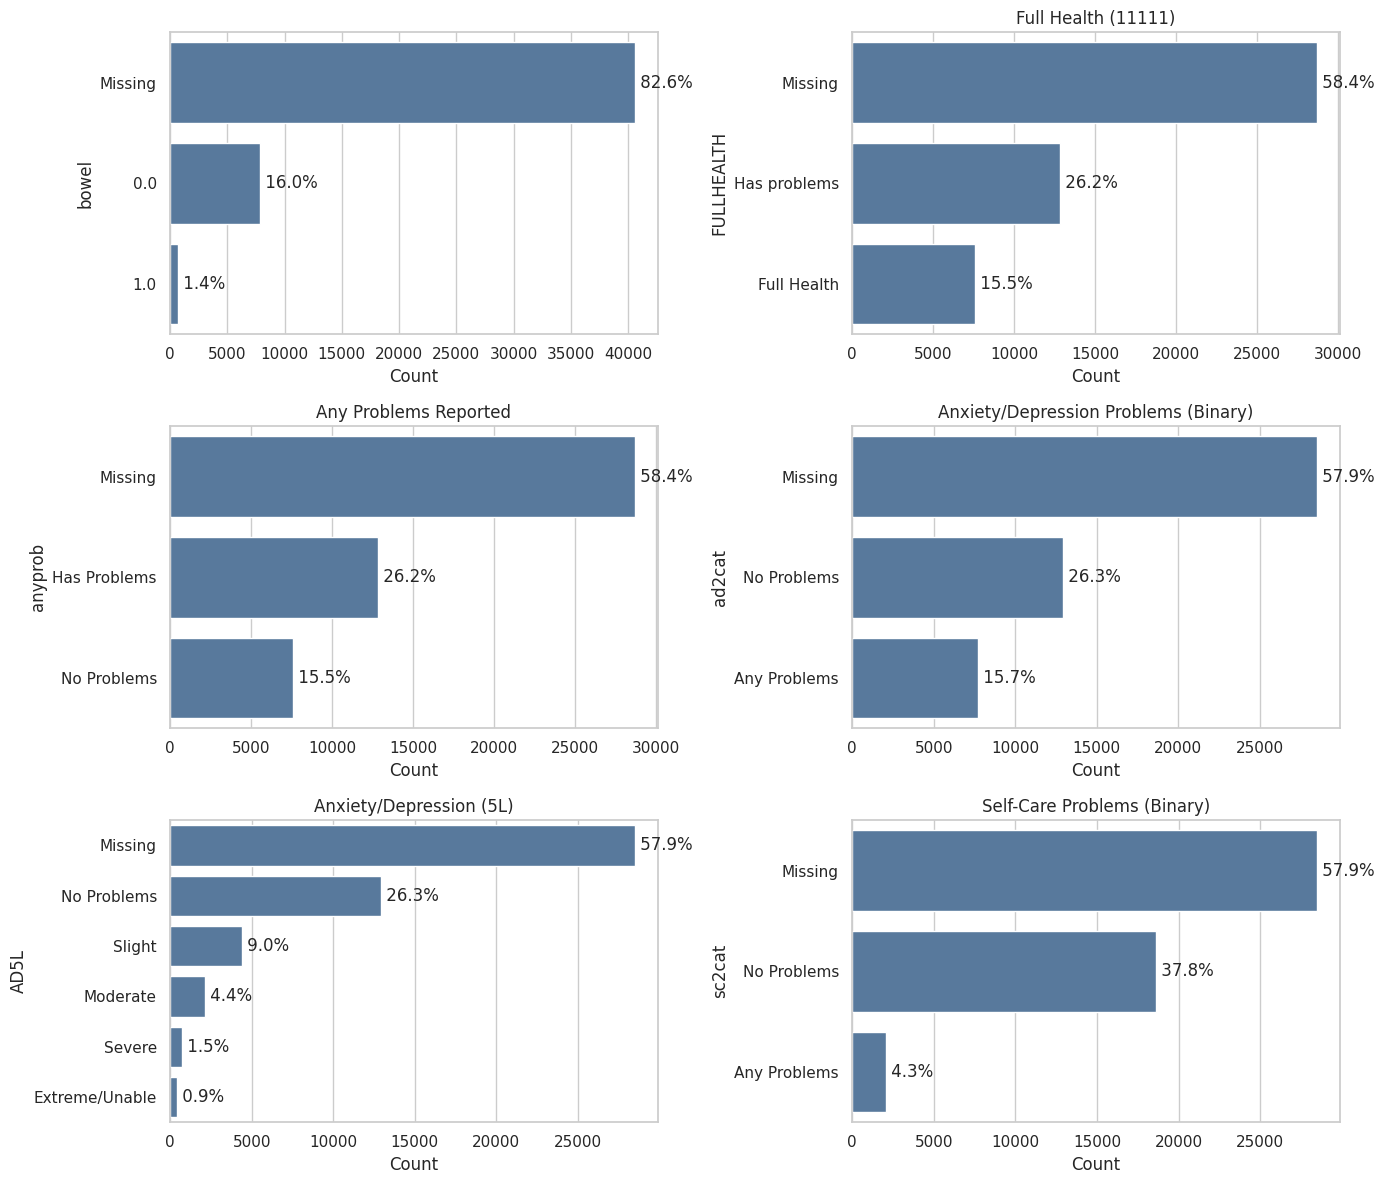

In [19]:
plot_categoricals = [
    column
    for column in category_summary.index
    if 1 < df[column].nunique(dropna=True) <= 8
][:6]

if plot_categoricals:
    n_cols = 2
    n_rows = math.ceil(len(plot_categoricals) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
    axes = np.atleast_1d(axes).ravel()

    for axis, column in zip(axes, plot_categoricals):
        counts = category_display_series(df[column]).value_counts(dropna=False)
        sns.barplot(x=counts.values, y=counts.index, ax=axis, color="#4C78A8")
        axis.set_title(var_labels.get(column, column))
        axis.set_xlabel("Count")
        axis.set_ylabel(column)

        for idx, value in enumerate(counts.values):
            axis.text(value, idx, f" {value / len(df):.1%}", va="center")

    for axis in axes[len(plot_categoricals):]:
        axis.remove()

    plt.tight_layout()
    plt.savefig(PLOTS_PATH / "categorical_distributions.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No categorical variables met the plotting heuristic.")

In [20]:
if "dataset" in df.columns:
    comparison_categoricals = [column for column in plot_categoricals if column != "dataset"][:4]

    if comparison_categoricals:
        dataset_series = category_display_series(df["dataset"])

        for column in comparison_categoricals:
            print(f"Distribution of {column} within each dataset")
            display(
                pd.crosstab(
                    dataset_series,
                    category_display_series(df[column]),
                    normalize="index",
                    dropna=False,
                ).round(3)
            )
    else:
        print("No categorical variables were eligible for a dataset comparison table.")
else:
    print("The dataframe does not contain a dataset column for grouped categorical comparisons.")

Distribution of bowel within each dataset


bowel,0.0,1.0,Missing
dataset,,,
DAPHNIE 2023,0.924,0.076,0.000
DAPHNIE 2024,0.250,0.028,0.721
HSE 2017,0.000,0.000,1.000
HSE 2018,0.261,0.015,0.725
HSE 2019,0.000,0.000,1.000
HSE 2022,0.000,0.000,1.000


Distribution of FULLHEALTH within each dataset


FULLHEALTH,Full Health,Has problems,Missing
dataset,,,
DAPHNIE 2023,0.199,0.549,0.252
DAPHNIE 2024,0.088,0.210,0.702
HSE 2017,0.381,0.516,0.104
HSE 2018,0.346,0.540,0.114
HSE 2019,0.000,0.000,1.000
HSE 2022,0.000,0.000,1.000


Distribution of anyprob within each dataset


anyprob,Has Problems,Missing,No Problems
dataset,,,
DAPHNIE 2023,0.549,0.252,0.199
DAPHNIE 2024,0.210,0.702,0.088
HSE 2017,0.516,0.104,0.381
HSE 2018,0.540,0.114,0.346
HSE 2019,0.000,1.000,0.000
HSE 2022,0.000,1.000,0.000


Distribution of ad2cat within each dataset


ad2cat,Any Problems,Missing,No Problems
dataset,,,
DAPHNIE 2023,0.392,0.252,0.355
DAPHNIE 2024,0.151,0.699,0.150
HSE 2017,0.276,0.092,0.632
HSE 2018,0.296,0.107,0.597
HSE 2019,0.000,1.000,0.000
HSE 2022,0.000,1.000,0.000


## Dataset Bias Diagnostics

This section checks whether the concatenated datasets differ systematically in sample composition, missingness, and feature patterns. A strong ability to predict dataset membership from the remaining variables is evidence of dataset-specific bias or batch effects.

Dataset composition


,n_rows,share_pct
dataset,,
DAPHNIE 2024,14849,30.220
HSE 2019,8204,16.690
HSE 2018,8178,16.640
HSE 2017,7997,16.270
HSE 2022,7729,15.730
DAPHNIE 2023,2184,4.440


Columns with the largest between-dataset missingness gaps


,overall_missing_pct,between_dataset_gap_pct
bowel,82.560,100.000
mus,54.780,100.000
resp,38.510,100.000
eth4cat,32.540,100.000
util_rowen,32.420,100.000
skin,42.960,99.990
emp_cat,42.250,99.790
edu_cat,25.850,99.540
educ_pst,42.050,99.470
PD5L,57.890,90.930


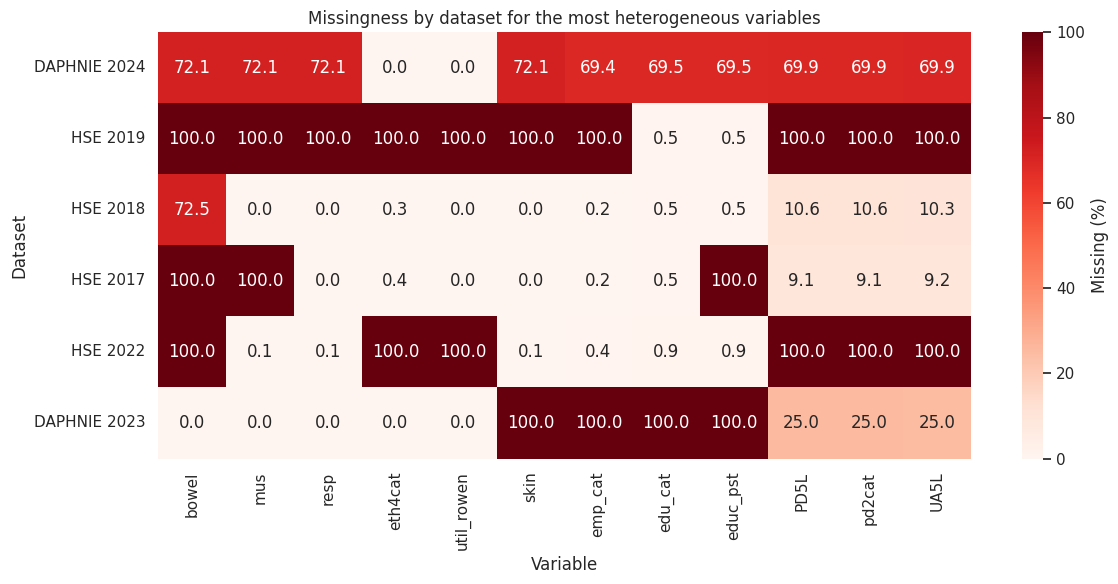

In [22]:
if "dataset" not in df.columns:
    raise KeyError("dataset column is not available in the dataframe.")

bias_dataset_counts = (
    df["dataset"]
    .value_counts(dropna=False)
    .rename_axis("dataset")
    .to_frame("n_rows")
)
bias_dataset_counts["share_pct"] = bias_dataset_counts["n_rows"].div(len(df)).mul(100).round(2)

print("Dataset composition")
display(bias_dataset_counts)

bias_missingness = pd.DataFrame(
    {
        dataset_name: df.loc[df["dataset"] == dataset_name].isna().mean().mul(100)
        for dataset_name in bias_dataset_counts.index
    }
).T

bias_missing_gap = (bias_missingness.max(axis=0) - bias_missingness.min(axis=0)).sort_values(ascending=False)
bias_missing_summary = pd.DataFrame(
    {
        "overall_missing_pct": df.isna().mean().mul(100),
        "between_dataset_gap_pct": bias_missing_gap,
    }
).sort_values(["between_dataset_gap_pct", "overall_missing_pct"], ascending=False)

print("Columns with the largest between-dataset missingness gaps")
display(bias_missing_summary.head(15).round(2))

bias_heatmap_cols = bias_missing_summary.head(12).index.tolist()
if bias_heatmap_cols:
    plt.figure(figsize=(12, 6))
    sns.heatmap(
        bias_missingness[bias_heatmap_cols],
        annot=True,
        fmt=".1f",
        cmap="Reds",
        cbar_kws={"label": "Missing (%)"},
    )
    plt.title("Missingness by dataset for the most heterogeneous variables")
    plt.xlabel("Variable")
    plt.ylabel("Dataset")
    plt.tight_layout()
    plt.savefig(PLOTS_PATH / "dataset_missingness_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()

In [24]:
from catboost import CatBoostClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split

model_features = [column for column in df.columns if column != "dataset"]
X = df[model_features].copy()
y = df["dataset"].astype("string")

model_numeric_cols = [column for column in model_features if pd.api.types.is_numeric_dtype(X[column])]
model_categorical_cols = [column for column in model_features if column not in model_numeric_cols]

for column in model_categorical_cols:
    X[column] = X[column].astype("string").fillna("Missing")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y,
)

dummy_model = DummyClassifier(strategy="prior")
dummy_model.fit(X_train, y_train)
dummy_predictions = dummy_model.predict(X_test)

cat_feature_indices = [X.columns.get_loc(column) for column in model_categorical_cols]

bias_classifier = CatBoostClassifier(
    loss_function="MultiClass",
    eval_metric="TotalF1:average=Macro",
    iterations=400,
    depth=6,
    learning_rate=0.05,
    random_seed=42,
    verbose=False,
)
bias_classifier.fit(X_train, y_train, cat_features=cat_feature_indices)
bias_predictions = bias_classifier.predict(X_test).ravel()

bias_model_metrics = pd.DataFrame(
    [
        {
            "model": "Majority-class baseline",
            "accuracy": accuracy_score(y_test, dummy_predictions),
            "balanced_accuracy": balanced_accuracy_score(y_test, dummy_predictions),
        },
        {
            "model": "CatBoost dataset classifier",
            "accuracy": accuracy_score(y_test, bias_predictions),
            "balanced_accuracy": balanced_accuracy_score(y_test, bias_predictions),
        },
    ]
)

print("If the CatBoost classifier is materially better than the baseline, the datasets carry systematic differences.")
display(bias_model_metrics.round(3))

bias_confusion = pd.DataFrame(
    confusion_matrix(y_test, bias_predictions, labels=bias_classifier.classes_),
    index=bias_classifier.classes_,
    columns=bias_classifier.classes_,
)

print("Confusion matrix for dataset prediction")
display(bias_confusion)

bias_feature_importance = (
    pd.DataFrame(
        {
            "feature": X.columns,
            "importance": bias_classifier.get_feature_importance(),
        }
    )
    .sort_values("importance", ascending=False)
    .head(15)
)

print("Top features driving dataset separability")
display(bias_feature_importance.round(3))

If the CatBoost classifier is materially better than the baseline, the datasets carry systematic differences.


,model,accuracy,balanced_accuracy
0,Majority-class baseline,0.302,0.167
1,CatBoost dataset classifier,1.000,0.999


Confusion matrix for dataset prediction


,DAPHNIE 2023,DAPHNIE 2024,HSE 2017,HSE 2018,HSE 2019,HSE 2022
DAPHNIE 2023,546,0,0,0,0,0
DAPHNIE 2024,0,3713,0,0,0,0
HSE 2017,0,1,1998,0,0,0
HSE 2018,0,3,0,2042,0,0
HSE 2019,0,0,0,0,2051,0
HSE 2022,0,0,0,0,2,1930


Top features driving dataset separability


,feature,importance
31,mus,25.074
15,util_rowen,23.592
32,skin,19.494
20,eth4cat,13.826
30,bowel,3.981
23,educ_pst,3.694
21,emp_cat,1.644
6,srh,1.205
7,sat,0.988
25,smoke_ecig,0.982


In [ ]:
print("Dataset-bias summary")
display(bias_model_metrics.round(3))
print("Top 10 dataset-separating features")
display(bias_feature_importance.head(10).round(3))